In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error as mse
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.impute import SimpleImputer

In [3]:
train_file_path = 'train.csv'
test_file_path = 'test.csv'
submission_file_path = 'sample_submission.csv'
data_description_file_path = 'data_description.txt'

train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)
submission_df = pd.read_csv(submission_file_path)

In [4]:
train_df = train_df.drop('Id', axis=1)
train_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### EDA

In [5]:
pd.set_option('display.max_columns', None)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


c:\Users\anton\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


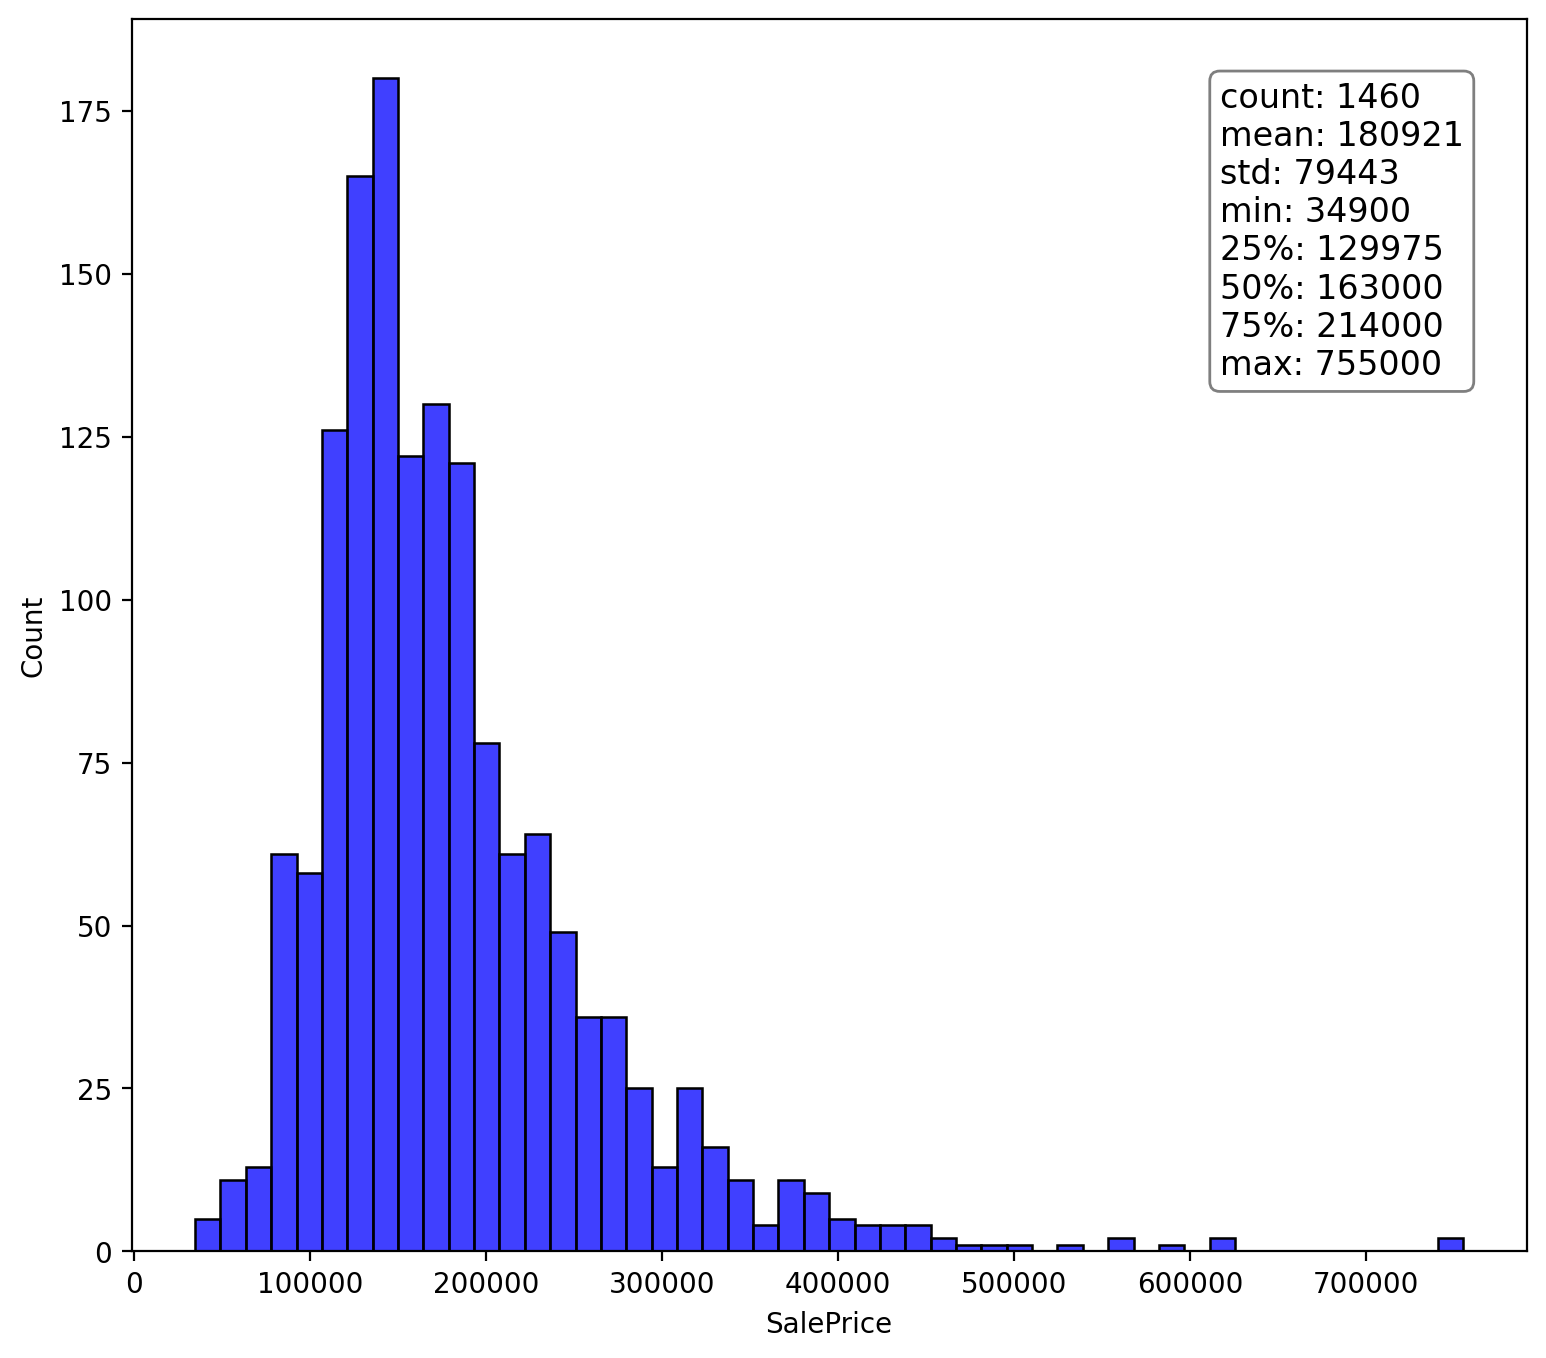

In [6]:
desc = train_df['SalePrice'].describe()
print(desc)

plt.figure(figsize=(9, 8), dpi=200)
sns.histplot(train_df['SalePrice'], color='b', bins=50)

stats_text = '\n'.join([
    f"count: {desc['count']:.0f}",
    f"mean: {desc['mean']:.0f}",
    f"std: {desc['std']:.0f}",
    f"min: {desc['min']:.0f}",
    f"25%: {desc['25%']:.0f}",
    f"50%: {desc['50%']:.0f}",
    f"75%: {desc['75%']:.0f}",
    f"max: {desc['max']:.0f}"
])

# Add the text box with stats to the plot
plt.text(0.78, 0.95, stats_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.show()

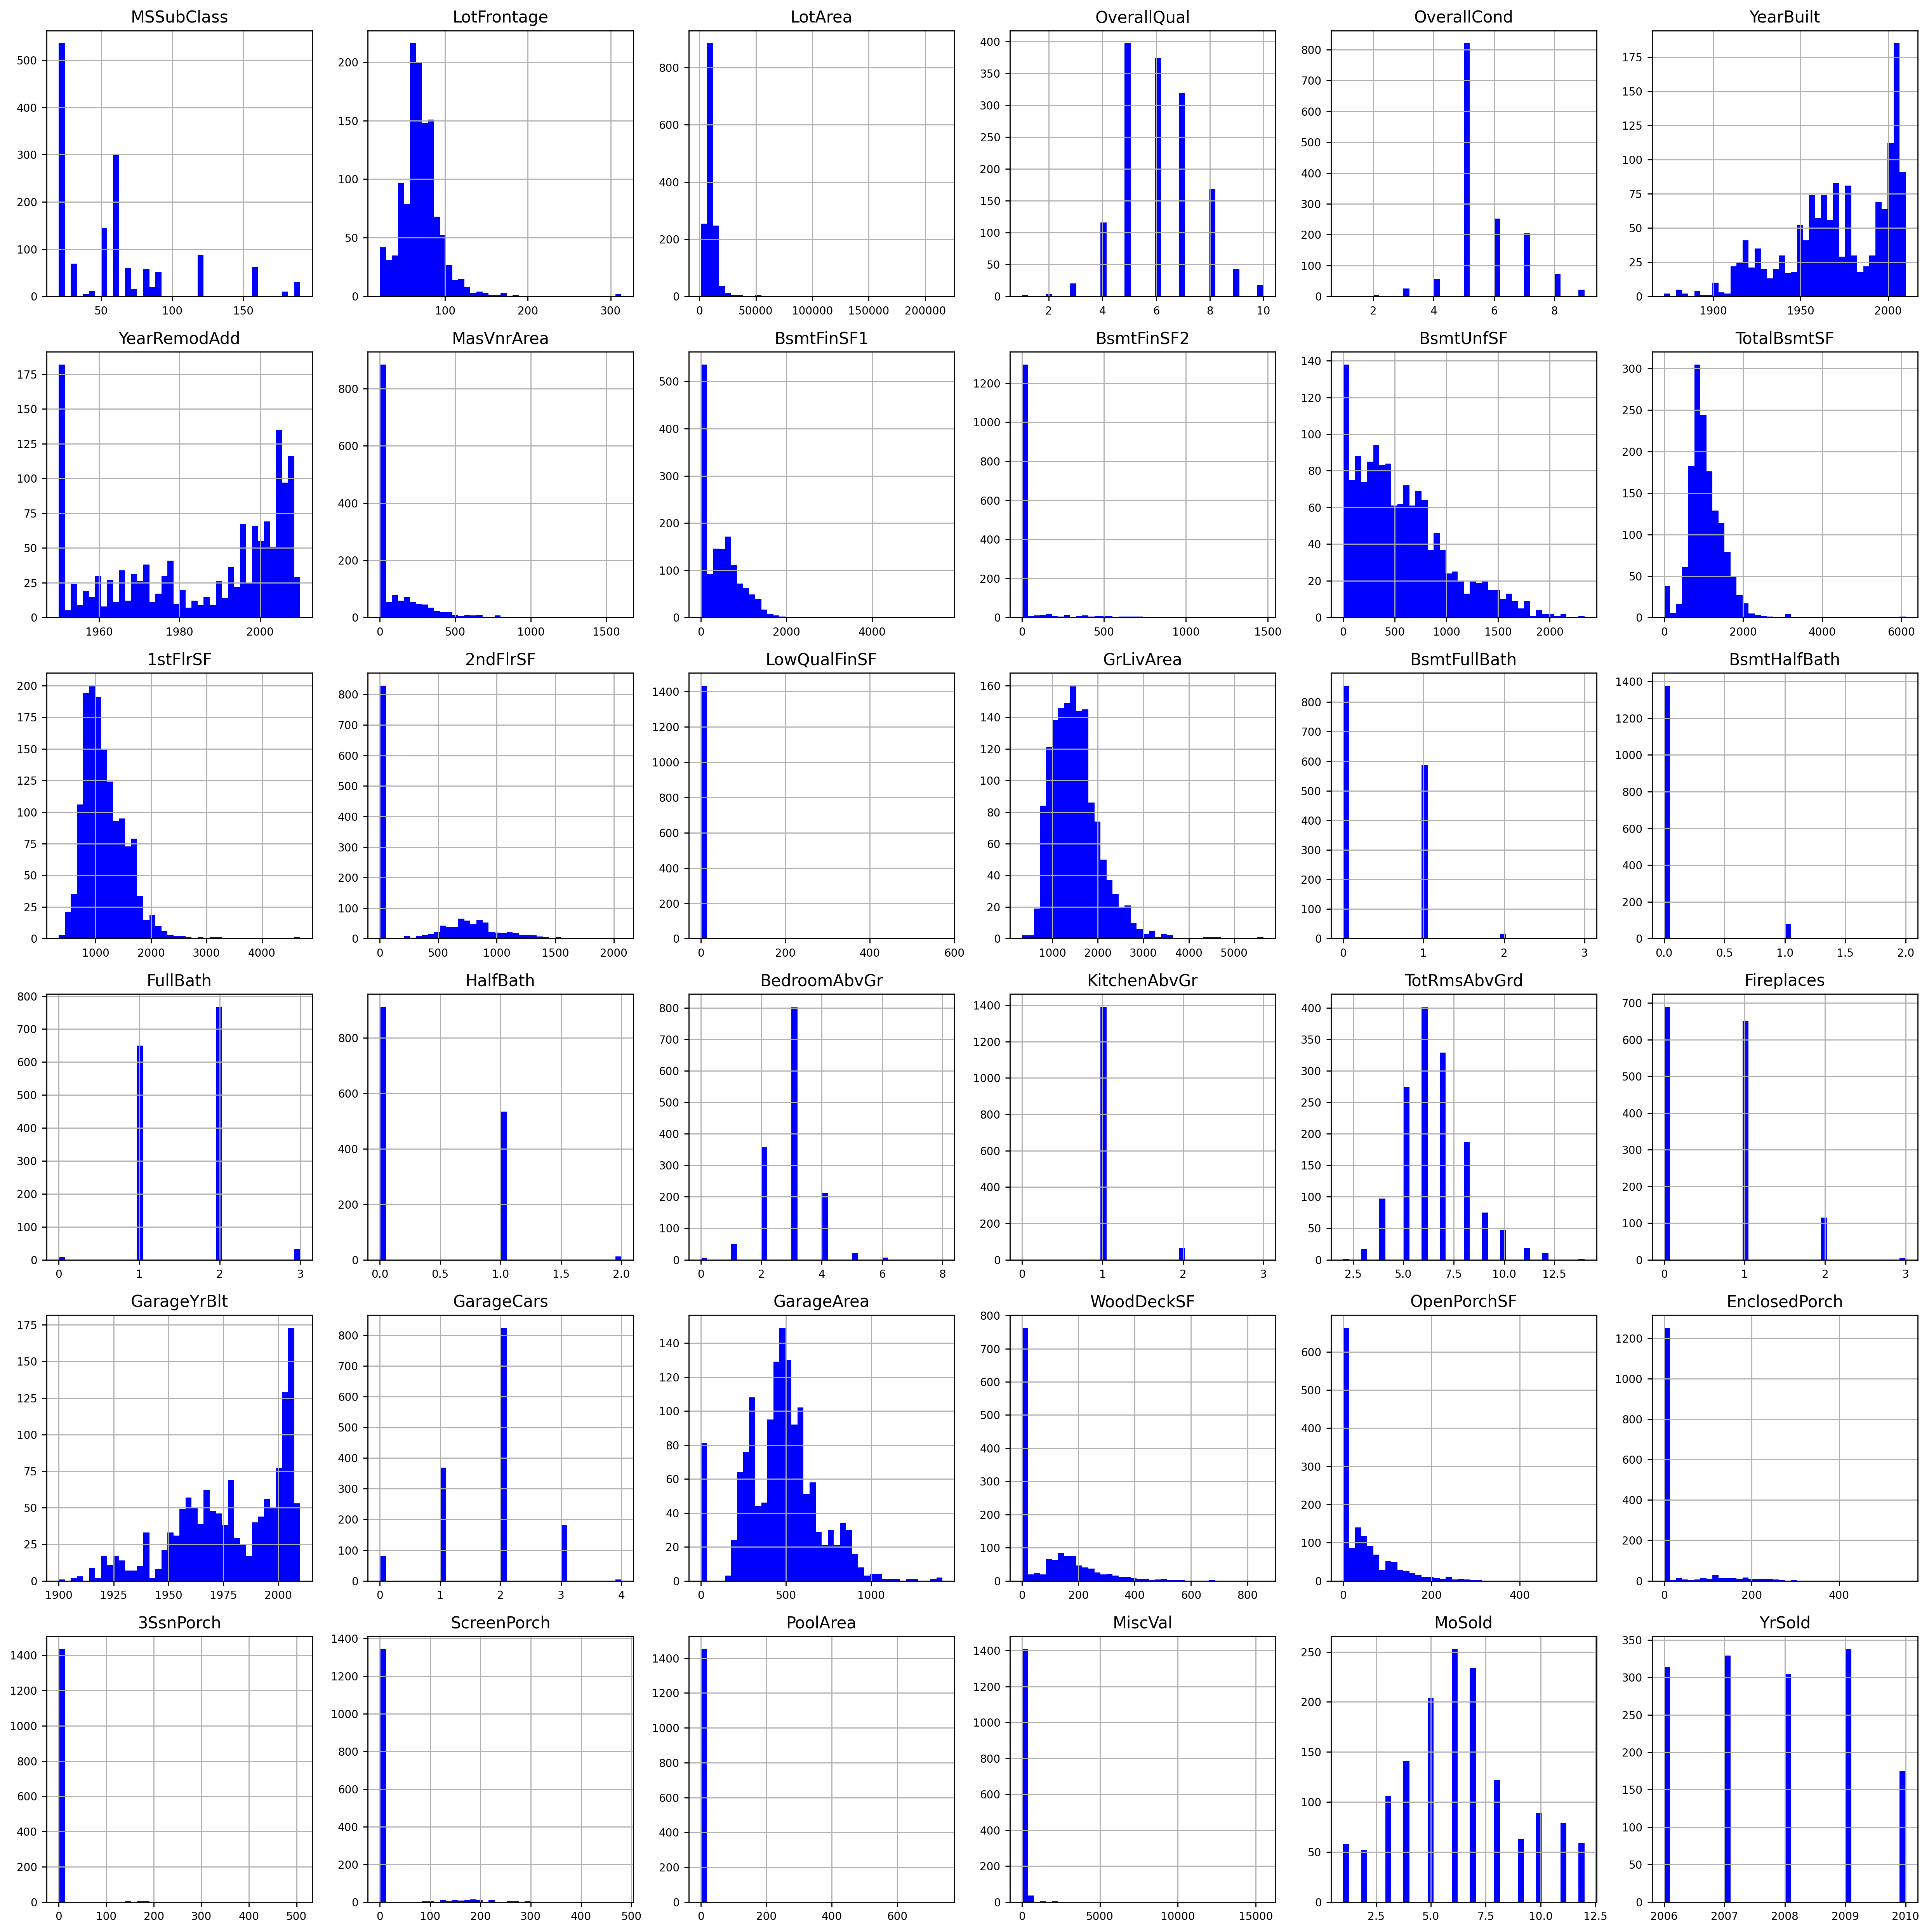

In [7]:
tempdf = train_df.drop(columns=['SalePrice'])
df_num = tempdf.select_dtypes(include = ['float64', 'int64'])
ax = df_num.hist(figsize=(20, 20), bins=40, xlabelsize=8, ylabelsize=8, color='b')
plt.tight_layout()
plt.gcf().set_dpi(250)
plt.show()


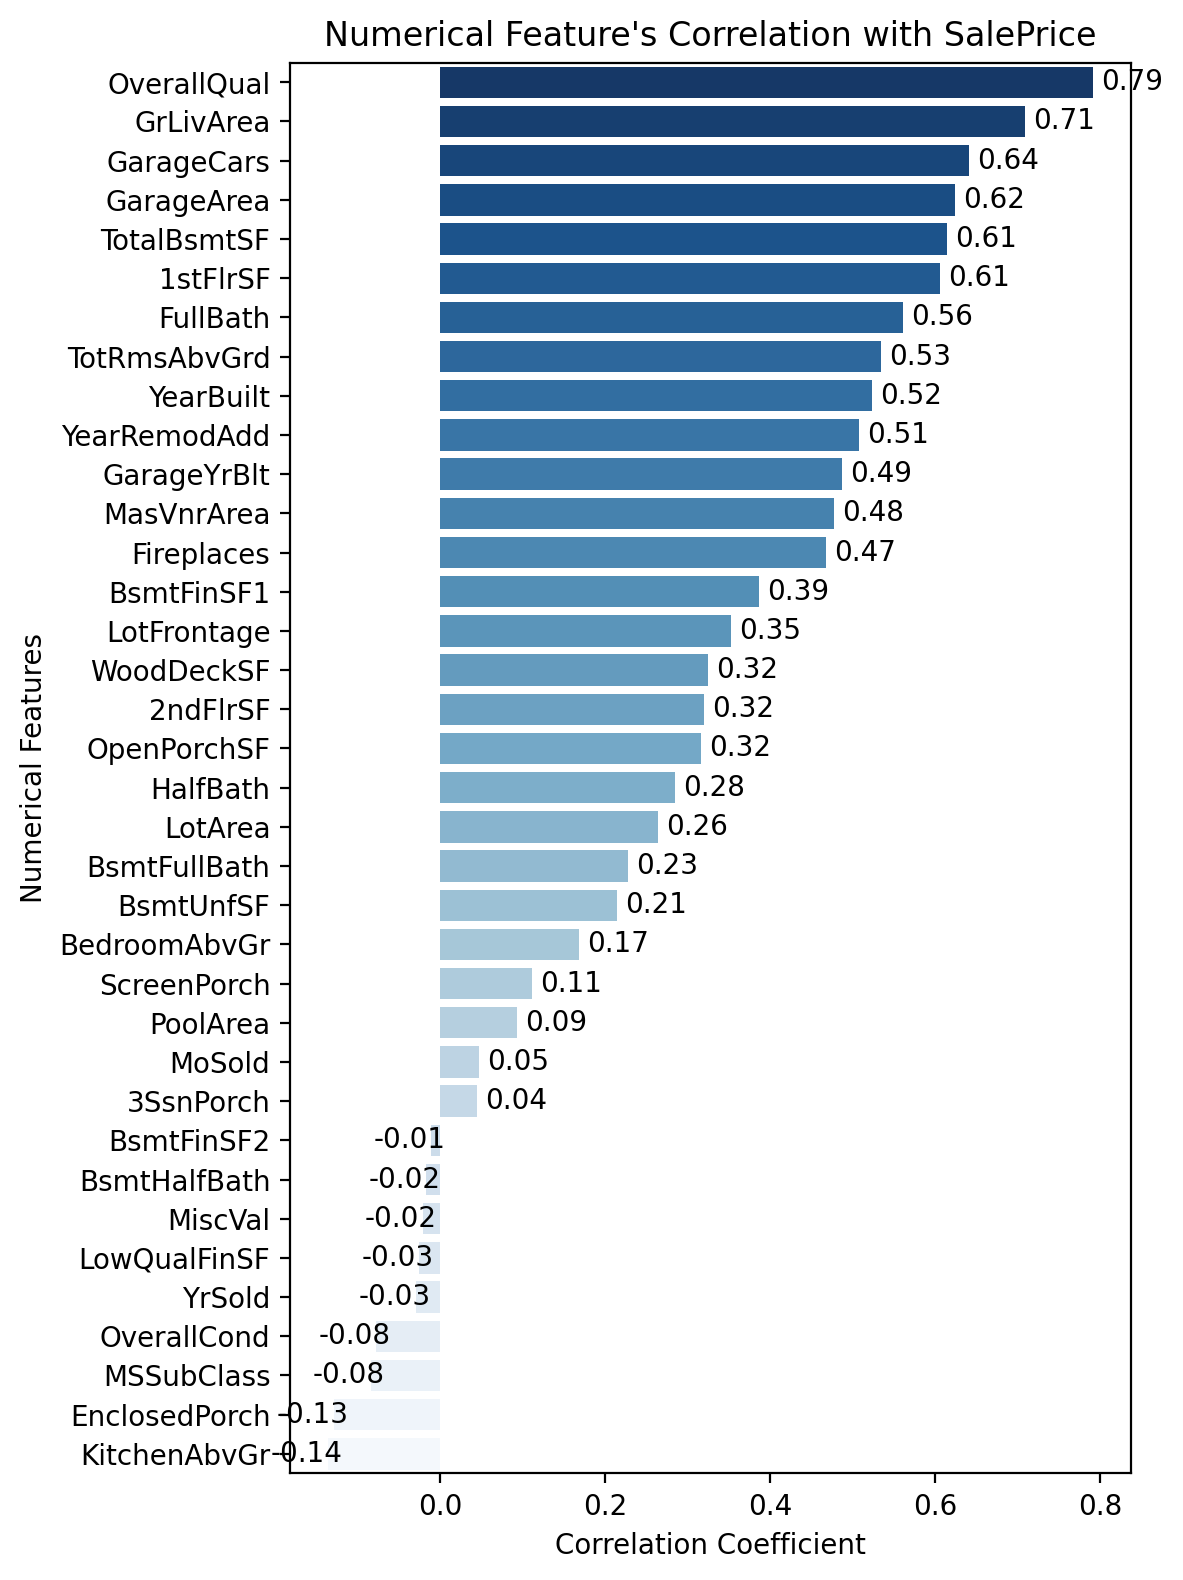

In [8]:
# Select numerical features only
num_df = train_df.select_dtypes(include=['int64', 'float64'])

sale_corr = num_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)
# print(sale_corr)

plt.figure(figsize=(6, 8), dpi=200)
sns.barplot(x=sale_corr.values, y=sale_corr.index, palette='Blues_r')
plt.title("Numerical Feature's Correlation with SalePrice")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Numerical Features")

# add correlation values to the bars
for i, v in enumerate(sale_corr.values):
    offset = 0.01 if v >= 0 else -0.07  # shift text slightly to avoid overlap
    plt.text(v + offset, i, f"{v:.2f}", color='black', va='center')
plt.tight_layout()
plt.show()

### Baseline Models

In [9]:
train_df_dum = pd.get_dummies(train_df) # so that random forest can work
# train_df = train_df.drop(columns=train_df.select_dtypes(include=['object']).columns)

X = train_df_dum.drop('SalePrice', axis=1)
y = train_df_dum['SalePrice']

X_train, X_val, y_train, y_val = train_test_split(X,y, test_size=0.2, random_state=21)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [10]:
# make a random forest model
rf = RandomForestRegressor(n_estimators = 200, random_state=21)  
rf.fit(X_train_scaled, y_train)

# predict using rf model
y_pred = rf.predict(X_val_scaled)
rmse =  np.sqrt(mse(y_val, y_pred))

# predict the mean of the training set every time. For baseline measurement
baseline_pred = np.full_like(y_val, np.mean(y_train))
base_rmse = np.sqrt(mse(baseline_pred, y_pred))
 
print("ACCURACY OF RANDOM FOREST MODEL:", rmse)
print("BASE ACCURACY OF THE MODEL guessing only mean value:", base_rmse)

# rmse of model with only numerical columns: 33736 , n_estimators = 200, random_state=21
# rmse of model with all columns: 32822, n_estimators = 200, random_state=21

ACCURACY OF RANDOM FOREST MODEL: 32771.88405673263
BASE ACCURACY OF THE MODEL guessing only mean value: 72689.32604524076


In [11]:
xgb_train = xgb.DMatrix(X_train, y_train, enable_categorical=True)
xgb_test = xgb.DMatrix(X_val, y_val, enable_categorical=True)
model = xgb.XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=21)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
rmse = np.sqrt(mse(y_val, y_pred))
print("ACCURACY OF XGBOOST MODEL:", rmse)

ACCURACY OF XGBOOST MODEL: 31853.642303510598


In [12]:
lr = LinearRegression()
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_val_imputed = imputer.transform(X_val_scaled)
lr.fit(X_train_imputed, y_train)
y_pred = lr.predict(X_val_imputed)
rmse = np.sqrt(mse(y_val, y_pred))
print("RMSE of linear regression:", rmse)

RMSE of linear regression: 37345.65399822965


### Data Cleaning

In [13]:
# TRAIN fill in missing values for certain features with typical/standard values
train_df['Functional'] = train_df['Functional'].fillna('Typ') # fill in nan with "typcial functionality"
train_df['Electrical'] = train_df['Electrical'].fillna('SBrkr') # fill in nan with "Standard Circuit Breakers & Romex"
train_df["PoolQC"] = train_df["PoolQC"].fillna("None") # no quality means no pool 
train_df['KitchenQual'] = train_df['KitchenQual'].fillna('TA') # fill with typical
# TEST
test_df['Functional'] = test_df['Functional'].fillna('Typ') # fill in nan with "typcial functionality"
test_df['Electrical'] = test_df['Electrical'].fillna('SBrkr') # fill in nan with "Standard Circuit Breakers & Romex"
test_df["PoolQC"] = test_df["PoolQC"].fillna("None") # no quality means no pool
test_df['KitchenQual'] = test_df['KitchenQual'].fillna('TA') # fill with typical

# TRAIN where typical values are not obvious, the most common values are reasonable replacement for missing data
train_df['Exterior1st'] = train_df['Exterior1st'].fillna(train_df['Exterior1st'].mode()[0])
train_df['Exterior2nd'] = train_df['Exterior2nd'].fillna(train_df['Exterior2nd'].mode()[0])
train_df['SaleType'] = train_df['SaleType'].fillna(train_df['SaleType'].mode()[0])
train_df['MSZoning'] = train_df['MSZoning'].fillna(train_df['MSZoning'].mode()[0])
train_df['LotFrontage'] = train_df['LotFrontage'].fillna(train_df['LotFrontage'].mode()[0])
# TEST
test_df['Exterior1st'] = test_df['Exterior1st'].fillna(test_df['Exterior1st'].mode()[0])
test_df['Exterior2nd'] = test_df['Exterior2nd'].fillna(test_df['Exterior2nd'].mode()[0])
test_df['SaleType'] = test_df['SaleType'].fillna(test_df['SaleType'].mode()[0])
test_df['MSZoning'] = test_df['MSZoning'].fillna(test_df['MSZoning'].mode()[0])
test_df['LotFrontage'] = test_df['LotFrontage'].fillna(test_df['LotFrontage'].mode()[0])

# TRAIN AND TEST missing values often mean there is no garage/basement so we fill with 0 or None
for col in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
    train_df[col] = train_df[col].fillna('None')
    test_df[col] = test_df[col].fillna('None')
for col in ('GarageYrBlt', 'GarageArea', 'GarageCars'):
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)
for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
    train_df[col] = train_df[col].fillna('None')
    test_df[col] = test_df[col].fillna('None')

# TRAIN AND TEST convert column that are currently numbers but actually represents categories
train_df['MSSubClass'] = train_df['MSSubClass'].astype(str)
test_df['MSSubClass'] = test_df['MSSubClass'].astype(str)

# TRAIN AND TEST fill missing values with None for the rest of the categorical columns
categorical_cols = [col for col in train_df.columns if train_df[col].dtype == object]
train_df[categorical_cols] = train_df[categorical_cols].fillna('None')
categorical_cols = [col for col in test_df.columns if test_df[col].dtype == object]
test_df[categorical_cols] = test_df[categorical_cols].fillna('None')

# TRAIN AND TEST fill missing values with 0 for the rest of the numeric columns
numeric_types = ['int64', 'float64']
numeric_cols = [col for col in train_df.columns if train_df[col].dtype in numeric_types]
train_df[numeric_cols] = train_df[numeric_cols].fillna(0)
numeric_cols = [col for col in test_df.columns if test_df[col].dtype in numeric_types]
test_df[numeric_cols] = test_df[numeric_cols].fillna(0)

# These preprocessing steps have been shown to improve the RMSE of a linear regression model 
# to approximately 36404.

### Feature Engineering

In [14]:
train_df['dataset'] = 'train'
test_df['dataset'] = 'test'

test_ids = test_df['Id']
test_df = test_df.drop(columns=['Id'])

concat_df = pd.concat([train_df, test_df], ignore_index=True)

# add features that summarize other features
concat_df['totalBathrooms'] = concat_df['FullBath'] + concat_df['HalfBath']
concat_df['totalSquareFootage'] = concat_df['TotalBsmtSF'] + concat_df['1stFlrSF'] + concat_df['2ndFlrSF']
concat_df['totalPorchSF'] = concat_df['OpenPorchSF'] + concat_df['EnclosedPorch'] + concat_df['3SsnPorch'] + concat_df['ScreenPorch'] 
concat_df['totalSF'] = concat_df['totalSquareFootage'] + concat_df['totalPorchSF'] + concat_df['GarageArea']
concat_df['totalRooms'] = concat_df['TotRmsAbvGrd'] + concat_df['totalBathrooms'] 

# make new binary features for features that are not binary
concat_df['haspool'] = concat_df['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
concat_df['has2ndfloor'] = concat_df['2ndFlrSF'].apply(lambda x: 1 if x > 0 else 0)
concat_df['hasbsmt'] = concat_df['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
concat_df['hasfireplace'] = concat_df['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)
concat_df['hasgarage'] = concat_df['GarageArea'].apply(lambda x: 1 if x > 0 else 0)

# some ratios
concat_df['bedroom_bathroom_ratio'] = concat_df['BedroomAbvGr'] / (concat_df['totalBathrooms'] +1)
concat_df['living_lot_ratio'] = concat_df['totalSquareFootage'] / (concat_df['LotArea']+1)
concat_df['finished_basement_ratio'] = concat_df['TotalBsmtSF'] / (concat_df['totalSquareFootage'] + 1)
concat_df['outdoor_living_ratio'] = concat_df['totalPorchSF'] / (concat_df['totalSquareFootage'] + 1)

# combination of many quality metrics
concat_df['property_score'] = (
    concat_df['OverallQual'] + # 1-10
    concat_df['OverallCond'] + # 1-10
    concat_df['ExterQual'].map({'Ex': 10, 'Gd': 8, 'TA': 6, 'Fa': 4, 'Po': 2})
) / 3

# quality-size interactions, these are very important!
concat_df['quality_size'] = concat_df['OverallQual'] * concat_df['totalSquareFootage']
concat_df['quality_size_holistic'] = concat_df['property_score'] * concat_df['totalSquareFootage']
concat_df['garage_quality'] = concat_df['GarageCars'] * concat_df['GarageArea'].fillna(0)

# neighborhood metrics, also pretty important
concat_df['relative_size_in_neighborhood'] = concat_df['totalSquareFootage'] / concat_df.groupby('Neighborhood')['totalSquareFootage'].transform('mean')
concat_df['relative_quality_in_neighborhood'] = concat_df['OverallQual'] / concat_df.groupby('Neighborhood')['OverallQual'].transform('mean')
concat_df['relative_age_in_neighborhood'] = concat_df['YearBuilt'] / concat_df.groupby('Neighborhood')['YearBuilt'].transform('mean')
concat_df['relative_quality_size_in_neighborhood'] = concat_df['quality_size'] / concat_df.groupby('Neighborhood')['quality_size'].transform('mean')
concat_df['relative_room_count_in_neighborhood'] = concat_df['totalRooms'] / concat_df.groupby('Neighborhood')['totalRooms'].transform('mean')
concat_df['relative_bedroom_count_in_neighborhood'] = concat_df['BedroomAbvGr'] / concat_df.groupby('Neighborhood')['BedroomAbvGr'].transform('mean')

# how the houses have aged
concat_df['age_of_house'] = 2020 - concat_df['YearBuilt']
concat_df['age_quality_interaction'] = concat_df['age_of_house'] / concat_df['OverallQual']

# living space efficiency
concat_df['space_efficiency'] = concat_df['totalSquareFootage'] / (concat_df['totalRooms'] + 1)

# more room quality metrics because they seem important 
concat_df['bedroom_quality'] = concat_df['BedroomAbvGr'] * concat_df['OverallQual']
concat_df['bathroom_bedroom_quality'] = (concat_df['totalBathrooms'] * concat_df['BedroomAbvGr']) * concat_df['OverallQual']

# more quality size interactions because quality size is important
concat_df['quality_size_per_room'] = concat_df['quality_size'] / (concat_df['totalRooms'] + 1)
concat_df['quality_size_ratio'] = concat_df['quality_size'] / (concat_df['LotArea'] + 1)

# need to save the dataset column before dummy encoding
ds_col = concat_df['dataset']
concat_df = pd.get_dummies(concat_df.drop(columns=['dataset'])).reset_index(drop=True)
concat_df['dataset'] = ds_col.values

concat_df = concat_df.copy() # to avoid defragmanted dataframe 

test_df = concat_df[concat_df['dataset'] == 'test'].drop(columns=['dataset'])
train_df = concat_df[concat_df['dataset'] == 'train'].drop(columns=['dataset'])


C:\Users\anton\AppData\Local\Temp\ipykernel_12024\2305411180.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  concat_df['relative_quality_in_neighborhood'] = concat_df['OverallQual'] / concat_df.groupby('Neighborhood')['OverallQual'].transform('mean')
C:\Users\anton\AppData\Local\Temp\ipykernel_12024\2305411180.py:44: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  concat_df['relative_age_in_neighborhood'] = concat_df['YearBuilt'] / concat_df.groupby('Neighborhood')['YearBuilt'].transform('mean')
C:\Users\anton\AppData\Local\T

Model Performance:
Linear Regression RMSE: $31,100.79
Gradient Boosting RMSE: $27,543.29


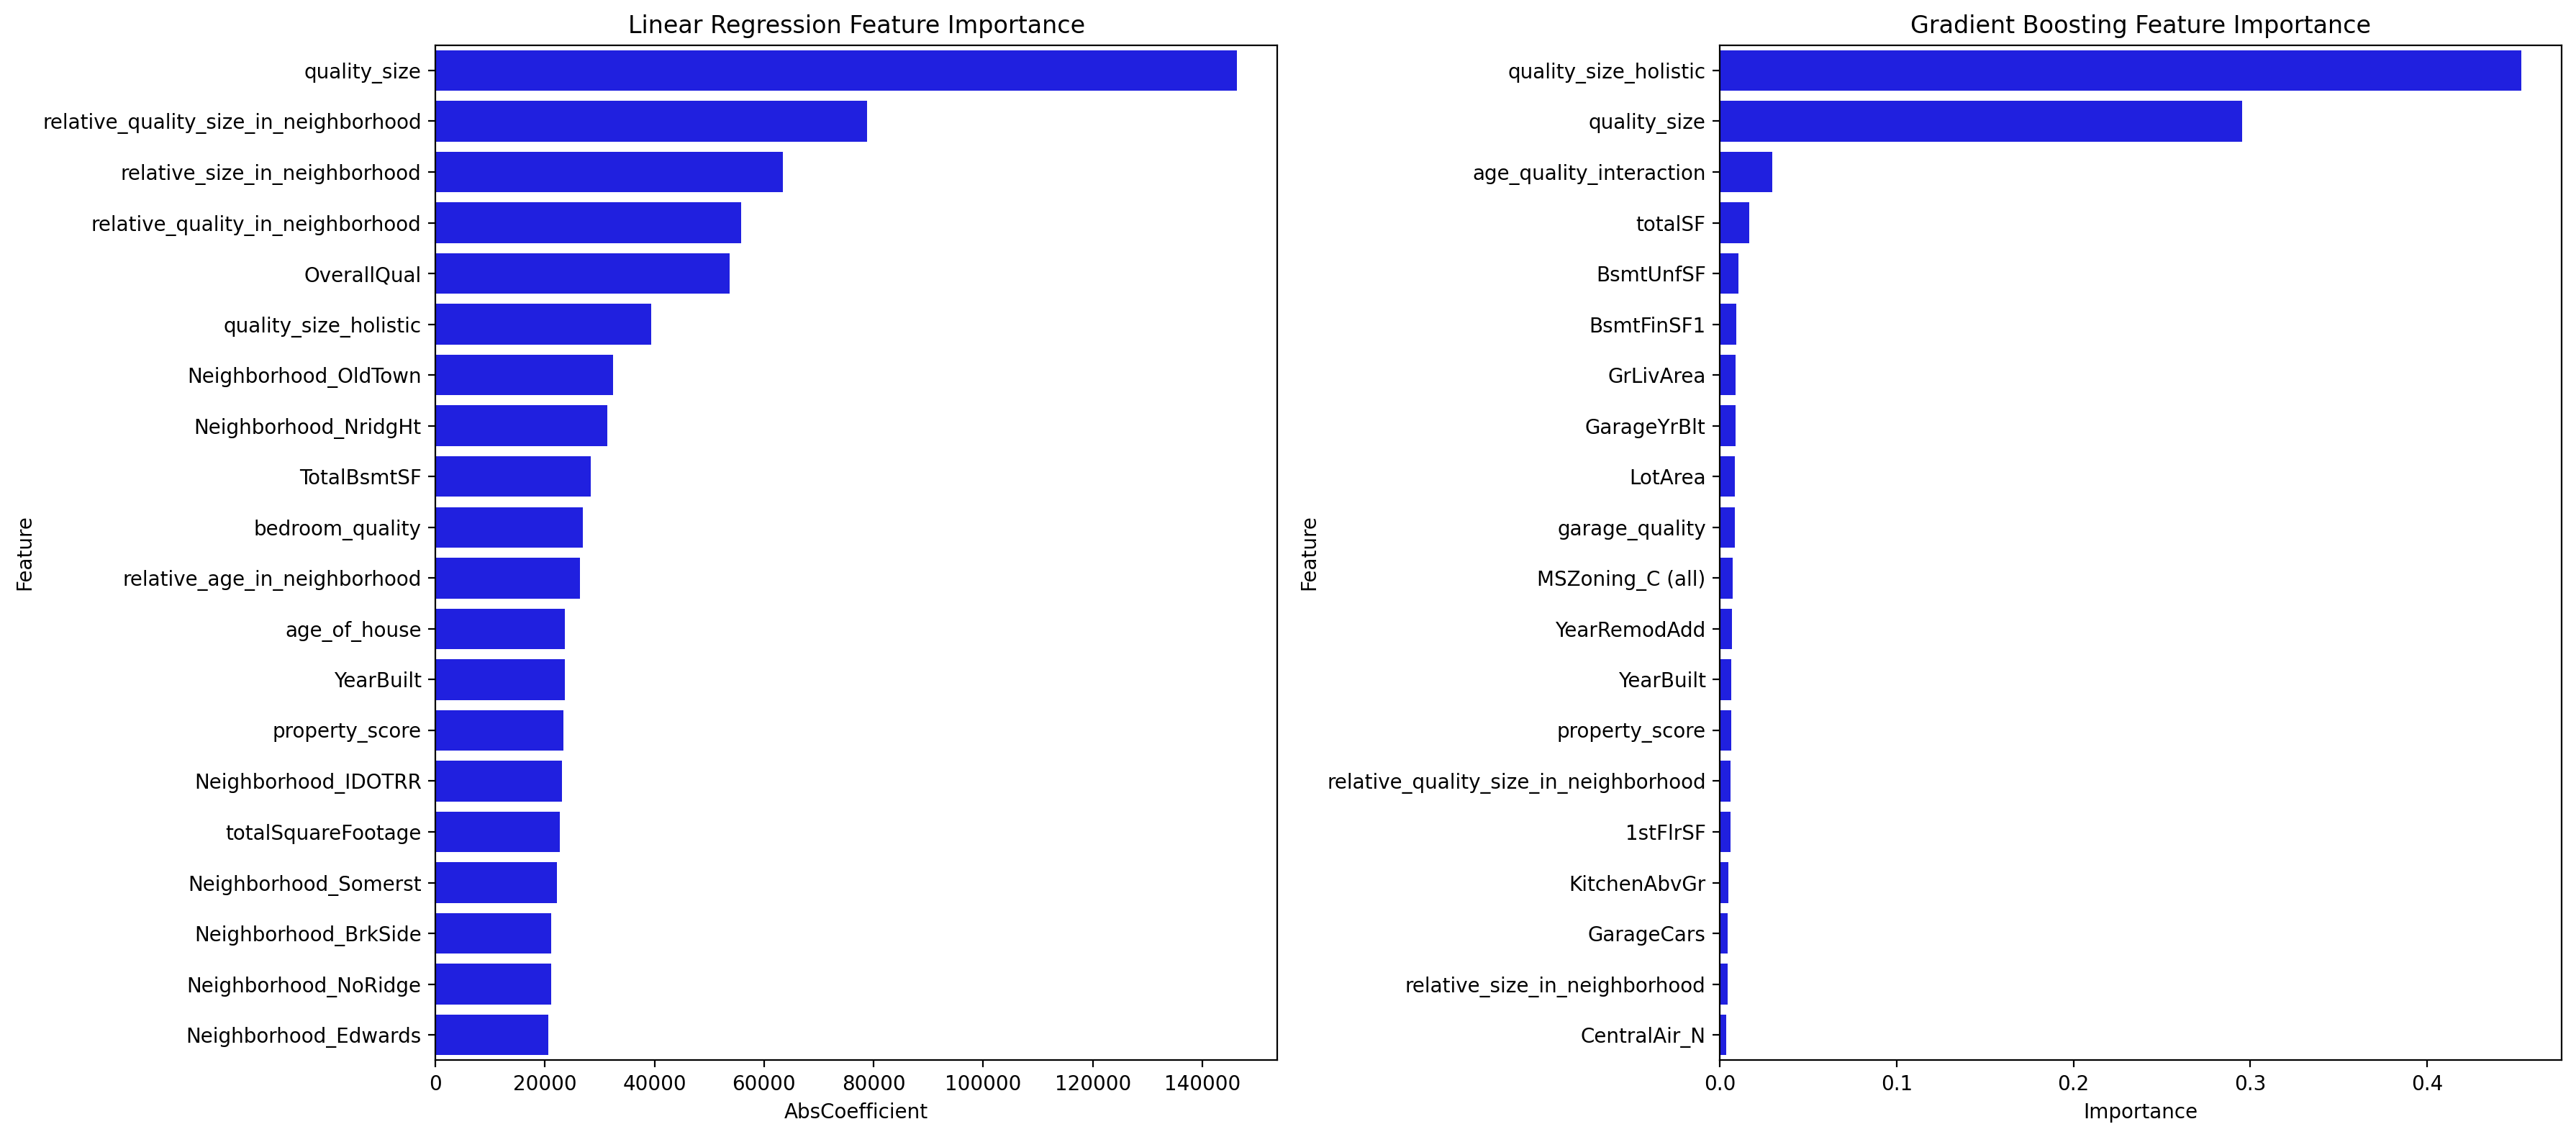

In [15]:
# FEATURE IMPORTANCE USING LINEAR REGRESSION AND GRADIENT BOOSTING
X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']
y_log = np.log1p(y)  # uses this for gradient boosting but could also do it for lr 

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=21)
X_train_log, X_val_log, y_train_log, y_val_log = train_test_split(X, y_log, test_size=0.2, random_state=21)

# scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#imputer
imputer = SimpleImputer(strategy="median")
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_val_imputed = imputer.transform(X_val_scaled)

# LR feature importance
lr = LinearRegression()
lr.fit(X_train_imputed, y_train)
y_pred = lr.predict(X_val_imputed)
rmse_lr = np.sqrt(mse(y_val, y_pred))

feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,  
    'Coefficient': lr.coef_
})
feature_importance_lr['AbsCoefficient'] = feature_importance_lr['Coefficient'].abs()
feature_importance_lr = feature_importance_lr.sort_values('AbsCoefficient', ascending=False)

# GB feature importance
gb = GradientBoostingRegressor( # arbitrary model 
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=4, 
    subsample=0.8,
    random_state=21
)
gb.fit(X_train_imputed, y_train_log)  
y_pred_gb_log = gb.predict(X_val_imputed)
y_pred_gb = np.expm1(y_pred_gb_log)  # convert back
rmse_gb = np.sqrt(mse(y_val, y_pred_gb))

feature_importance_gb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
})
feature_importance_gb = feature_importance_gb.sort_values('Importance', ascending=False)

# performance print
print("Model Performance:")
print(f"Linear Regression RMSE: ${rmse_lr:,.2f}")
print(f"Gradient Boosting RMSE: ${rmse_gb:,.2f}")

# plot 
fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=200)
sns.barplot(x='AbsCoefficient', y='Feature', data=feature_importance_lr.head(20), ax=axes[0], color='blue')
axes[0].set_title('Linear Regression Feature Importance')
sns.barplot(x='Importance', y='Feature', data=feature_importance_gb.head(20), ax=axes[1], color='blue')
axes[1].set_title('Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

Keeping 44 features with importance above 0.5%
Keeping 77 features with importance above 0.05%


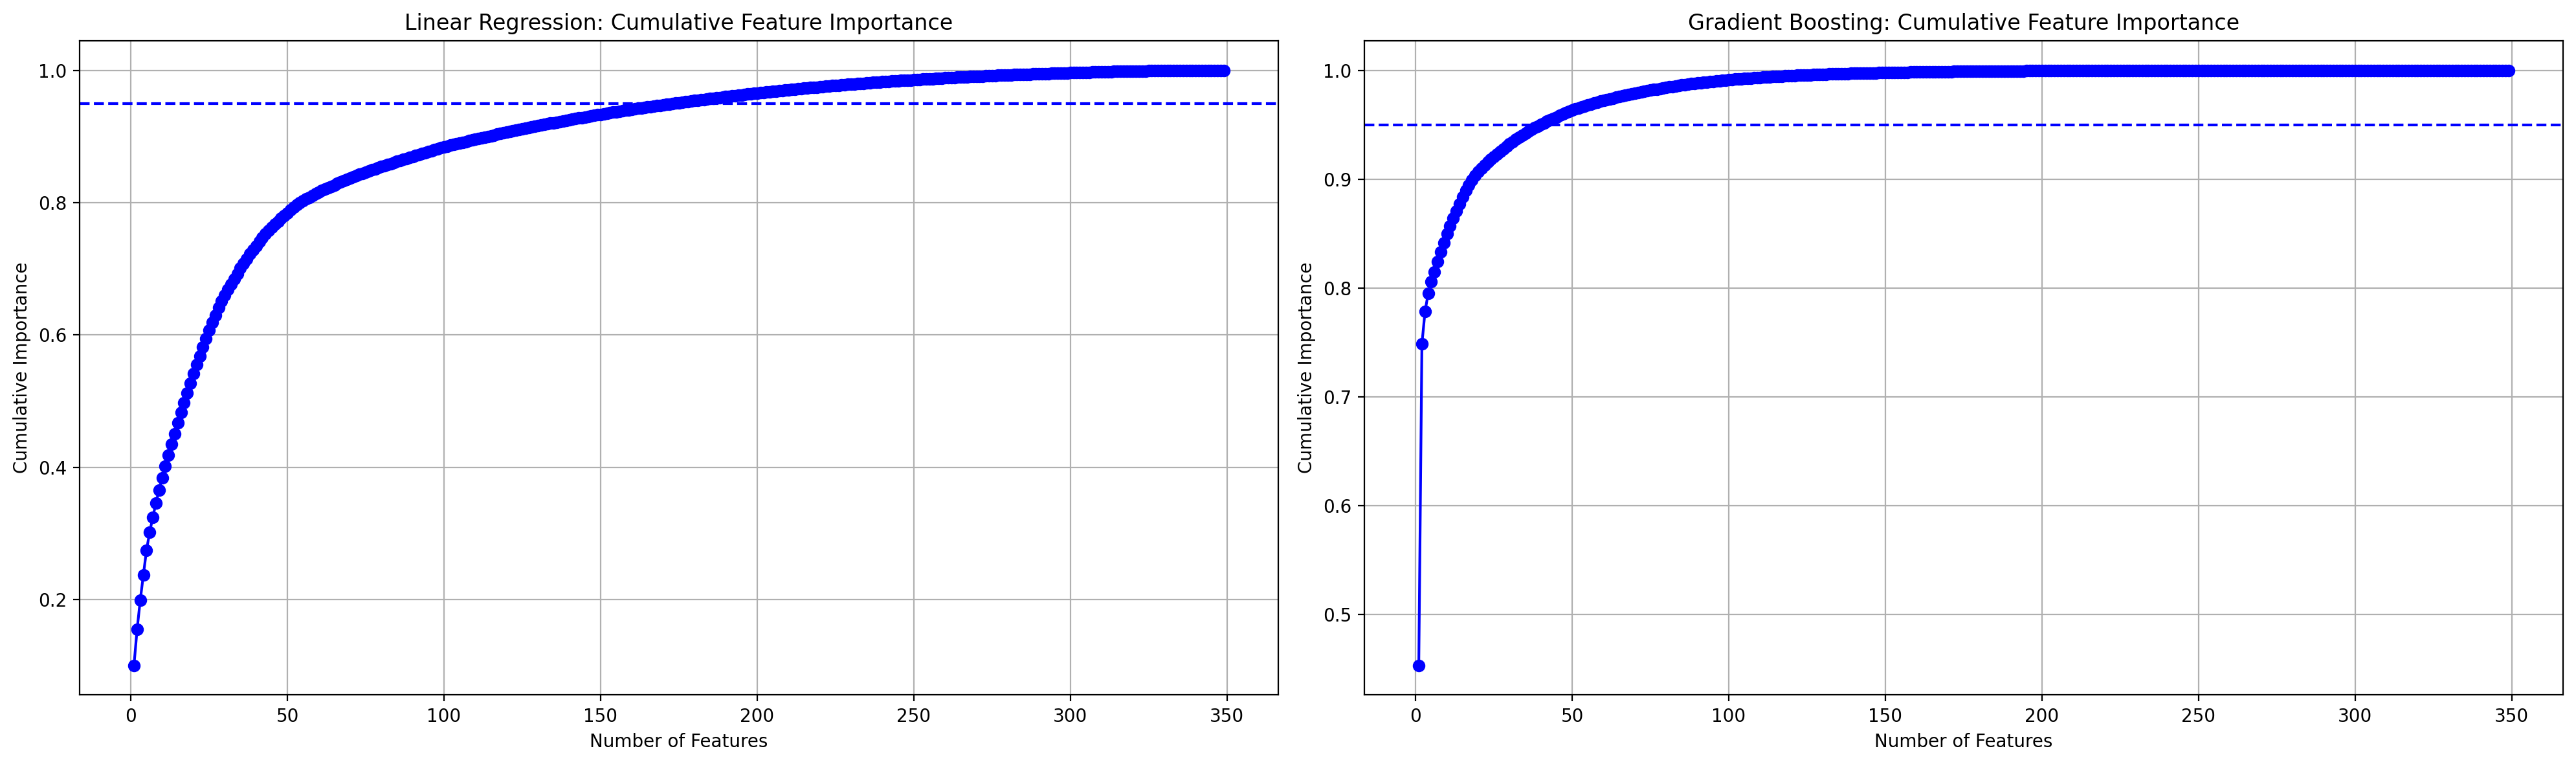

In [16]:
def select_important_features_lr(X, feature_importance, threshold=0.01):
    total_importance = feature_importance['AbsCoefficient'].sum()
    feature_importance['ImportancePercentage'] = feature_importance['AbsCoefficient'] / total_importance 
    important_features = feature_importance[feature_importance['ImportancePercentage'] > threshold]
    important_feature_names = important_features['Feature'].values
    print(f"Keeping {len(important_features)} features with importance above {threshold*100}%")
    return X[important_features['Feature']], important_feature_names

def select_important_features_gb(X, feature_importance, threshold=0.01):
    total_importance = feature_importance['Importance'].sum()
    feature_importance['ImportancePercentage'] = feature_importance['Importance'] / total_importance 
    important_features = feature_importance[feature_importance['ImportancePercentage'] > threshold]
    important_feature_names = important_features['Feature'].values
    print(f"Keeping {len(important_features)} features with importance above {threshold*100}%")
    return X[important_features['Feature']], important_feature_names

def apply_feature_selection(df, feature_names): # a bit redundant but it adds clarity 
    return df[feature_names]

# LR feature selection
X_important_lr, important_feature_names_lr = select_important_features_lr(X, feature_importance_lr, threshold=0.005)  
# GB feature selection
X_important_gb, important_feature_names_gb = select_important_features_gb(X, feature_importance_gb, threshold=0.0005)


# calculate and plot cumulative importance for both models
feature_importance_lr = feature_importance_lr.sort_values('AbsCoefficient', ascending=False)
feature_importance_lr['CumulativeImportance'] = feature_importance_lr['AbsCoefficient'].cumsum() / feature_importance_lr['AbsCoefficient'].sum()

feature_importance_gb = feature_importance_gb.sort_values('Importance', ascending=False)
feature_importance_gb['CumulativeImportance'] = feature_importance_gb['Importance'].cumsum() / feature_importance_gb['Importance'].sum()

fig, axes = plt.subplots(1, 2, figsize=(20, 6), dpi=200)

# LR cumulative importance
axes[0].plot(range(1, len(feature_importance_lr) + 1), feature_importance_lr['CumulativeImportance'], marker='o', color='blue')
axes[0].axhline(y=0.95, color='b', linestyle='--')
axes[0].set_xlabel('Number of Features')
axes[0].set_ylabel('Cumulative Importance')
axes[0].set_title('Linear Regression: Cumulative Feature Importance')
axes[0].grid(True)

# GB cumulative importance
axes[1].plot(range(1, len(feature_importance_gb) + 1), feature_importance_gb['CumulativeImportance'], marker='o', color='blue')
axes[1].axhline(y=0.95, color='b', linestyle='--')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].set_title('Gradient Boosting: Cumulative Feature Importance')
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Models

### Linear Regression

In [17]:
# WITH SELECTED FEATURES
X_train_sel, X_val_sel, y_train_sel, y_val_sel = train_test_split(X_important_lr, y, test_size=0.2, random_state=21)

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_val_sel_scaled = scaler_sel.transform(X_val_sel)

imputer_sel = SimpleImputer(strategy="median")
X_train_sel_imputed = imputer_sel.fit_transform(X_train_sel_scaled)
X_val_sel_imputed = imputer_sel.transform(X_val_sel_scaled)

# train
lr_selected = LinearRegression()
lr_selected.fit(X_train_sel_imputed, y_train_sel)
y_pred_sel = lr_selected.predict(X_val_sel_imputed)

# rmse
rmse_sel = np.sqrt(mse(y_val_sel, y_pred_sel))
print("RMSE of linear regression with selected features:", rmse_sel)

# with all features from previous run
print("RMSE of linear regression with all features:", rmse_lr) # from when doing the feature importance 

RMSE of linear regression with selected features: 35668.47259240218
RMSE of linear regression with all features: 31100.78915794255


Best alpha: 0.01
Training RMSE: 22252.70
Validation RMSE: 31984.13


Text(0.5, 1.0, 'Predicted vs Actual House Prices')

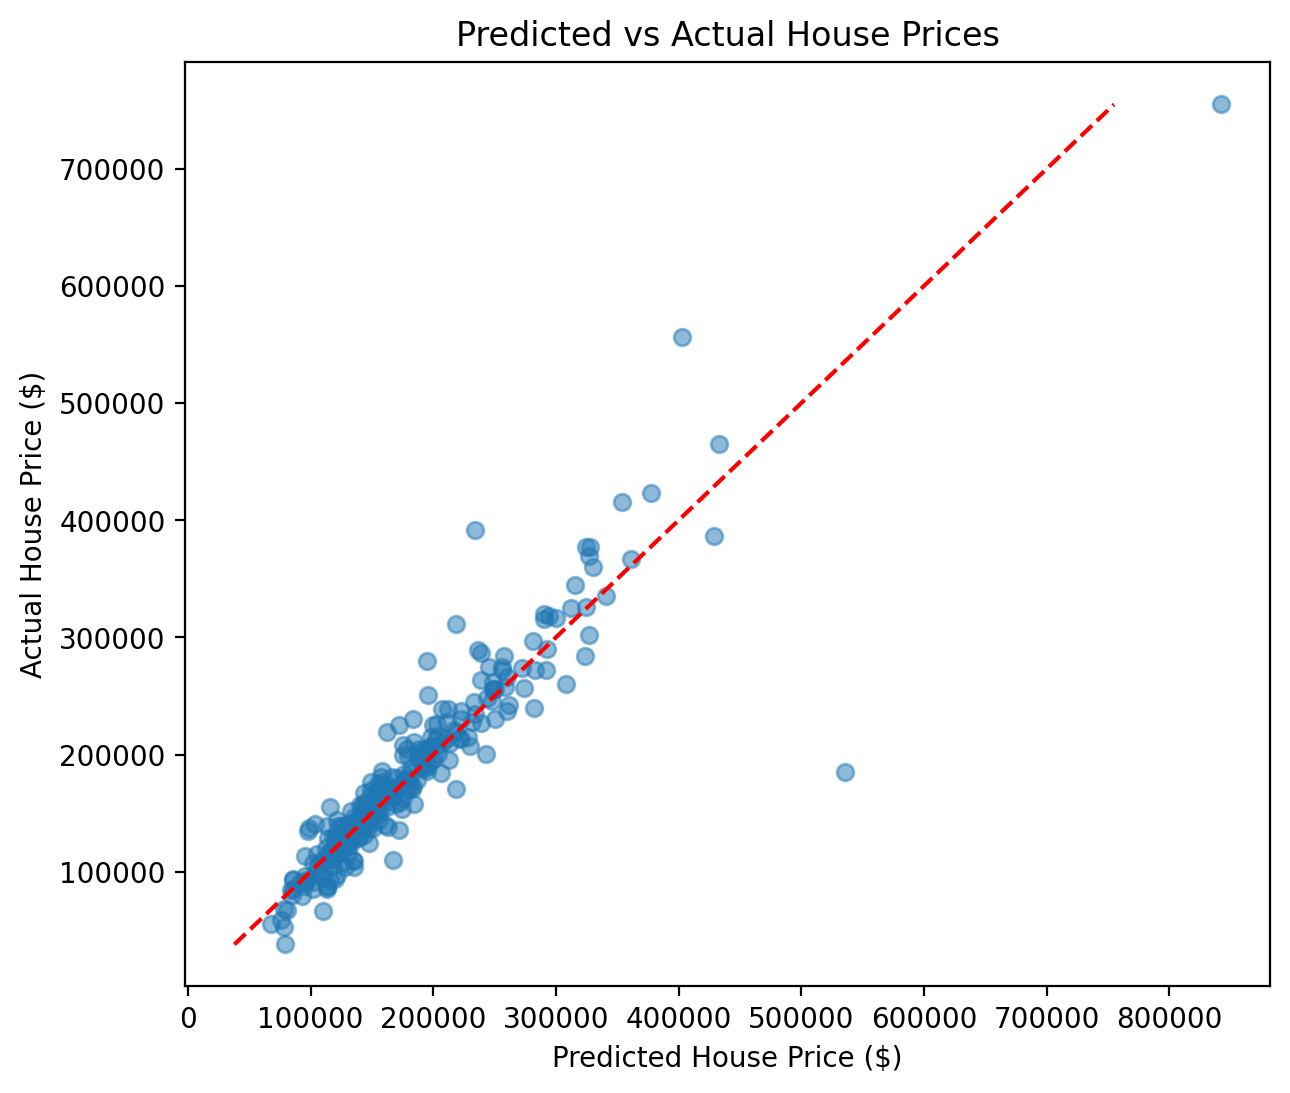

In [18]:
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_sel_imputed)
X_val_poly = poly.transform(X_val_sel_imputed)

param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

lasso_cv = GridSearchCV(
    Lasso(random_state=21, max_iter=10000), 
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

#save
y_train_original = y_train_sel.copy()  
y_val_original = y_val_sel.copy()

#log transform the target variable
y_train_log = np.log1p(y_train_sel) 
y_val_log = np.log1p(y_val_sel)

#fit
lasso_cv.fit(X_train_poly, y_train_log)
best_alpha = lasso_cv.best_params_['alpha']
print(f"Best alpha: {best_alpha}")

lasso_poly = Lasso(alpha=best_alpha, random_state=21, max_iter=20000)
lasso_poly.fit(X_train_poly, y_train_log)

# make predictions on log scale
y_pred_train_log = lasso_poly.predict(X_train_poly)
y_pred_val_log = lasso_poly.predict(X_val_poly)

# convert back to original scale
y_pred_train_original = np.expm1(y_pred_train_log)
y_pred_val_original = np.expm1(y_pred_val_log)

# evaluate model
train_rmse_original = np.sqrt(mse(y_train_original, y_pred_train_original))
val_rmse_original = np.sqrt(mse(y_val_original, y_pred_val_original))

print(f"Training RMSE: {train_rmse_original:.2f}")
print(f"Validation RMSE: {val_rmse_original:.2f}")

# plot results
plt.figure(figsize=(7, 6), dpi=200)
plt.scatter(y_pred_val_original, y_val_original, alpha=0.5)
plt.plot([y_val_original.min(), y_val_original.max()], 
         [y_val_original.min(), y_val_original.max()], 'r--')
plt.xlabel('Predicted House Price ($)')
plt.ylabel('Actual House Price ($)')
plt.title('Predicted vs Actual House Prices')

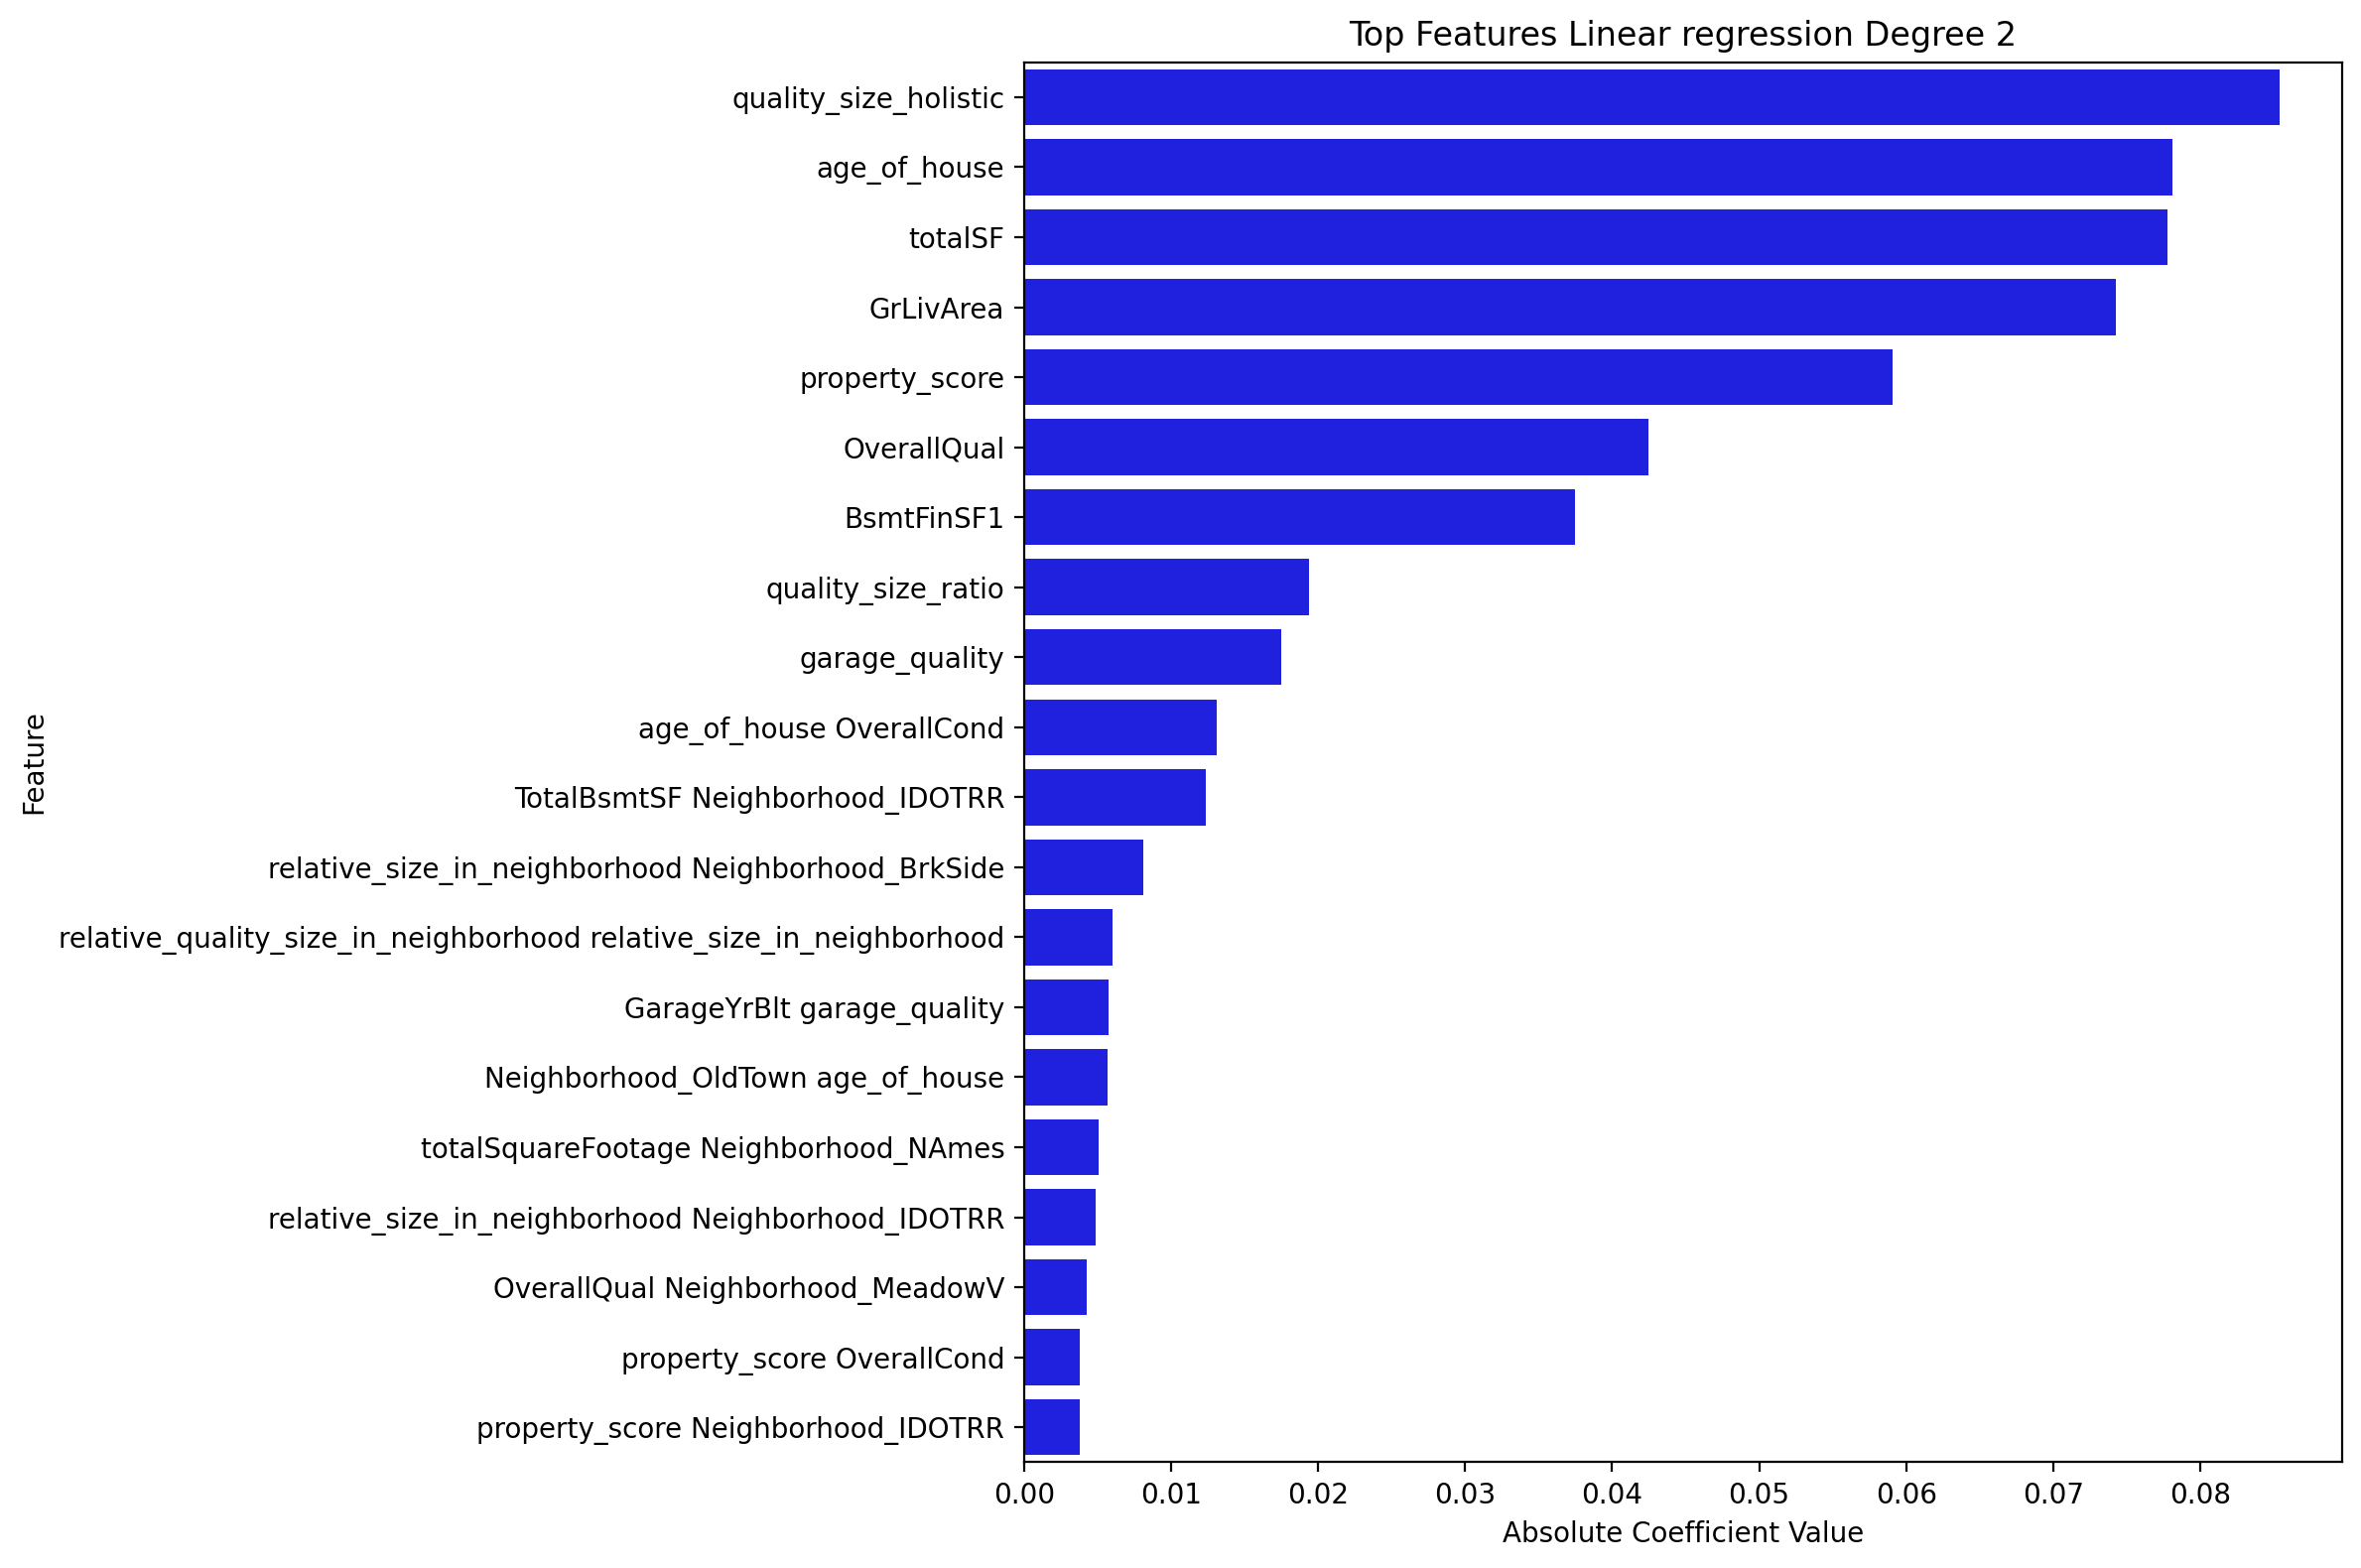

Top 10 features by importance:
                      Feature  Coefficient
5       quality_size_holistic     0.085381
11               age_of_house    -0.078126
23                    totalSF     0.077742
32                  GrLivArea     0.074232
13             property_score     0.059043
4                 OverallQual     0.042494
39                 BsmtFinSF1     0.037482
42         quality_size_ratio    -0.019387
30             garage_quality     0.017476
485  age_of_house OverallCond     0.013097

Number of features used by model (non-zero coefficients): 41 out of 990


In [29]:
# First, get the original feature names (assuming X_train_sel is a DataFrame)
# If X_train_sel_imputed is already a DataFrame, use X_train_sel_imputed.columns instead
original_feature_names = X_train_sel.columns

# Get polynomial feature names
poly_feature_names = poly.get_feature_names_out(input_features=original_feature_names)

# Create DataFrame with feature names and coefficients
feature_importance = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': lasso_poly.coef_
})

# Add absolute coefficient for sorting
feature_importance['AbsCoefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('AbsCoefficient', ascending=False)

# Plot top features
plt.figure(figsize=(12, 8), dpi=200)
top_n = 20  
top_features = feature_importance.head(top_n)

# Create bar plot
sns.barplot(x='AbsCoefficient', y='Feature', data=top_features, color='blue')
plt.title('Top Features Linear regression Degree 2')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Print top 10 features
print("Top 10 features by importance:")
print(feature_importance.head(10)[['Feature', 'Coefficient']])

# Count non-zero coefficients
non_zero_count = (feature_importance['Coefficient'] != 0).sum()
print(f"\nNumber of features used by model (non-zero coefficients): {non_zero_count} out of {len(feature_importance)}")

Predictions saved to 'lasso_poly_submission.csv'


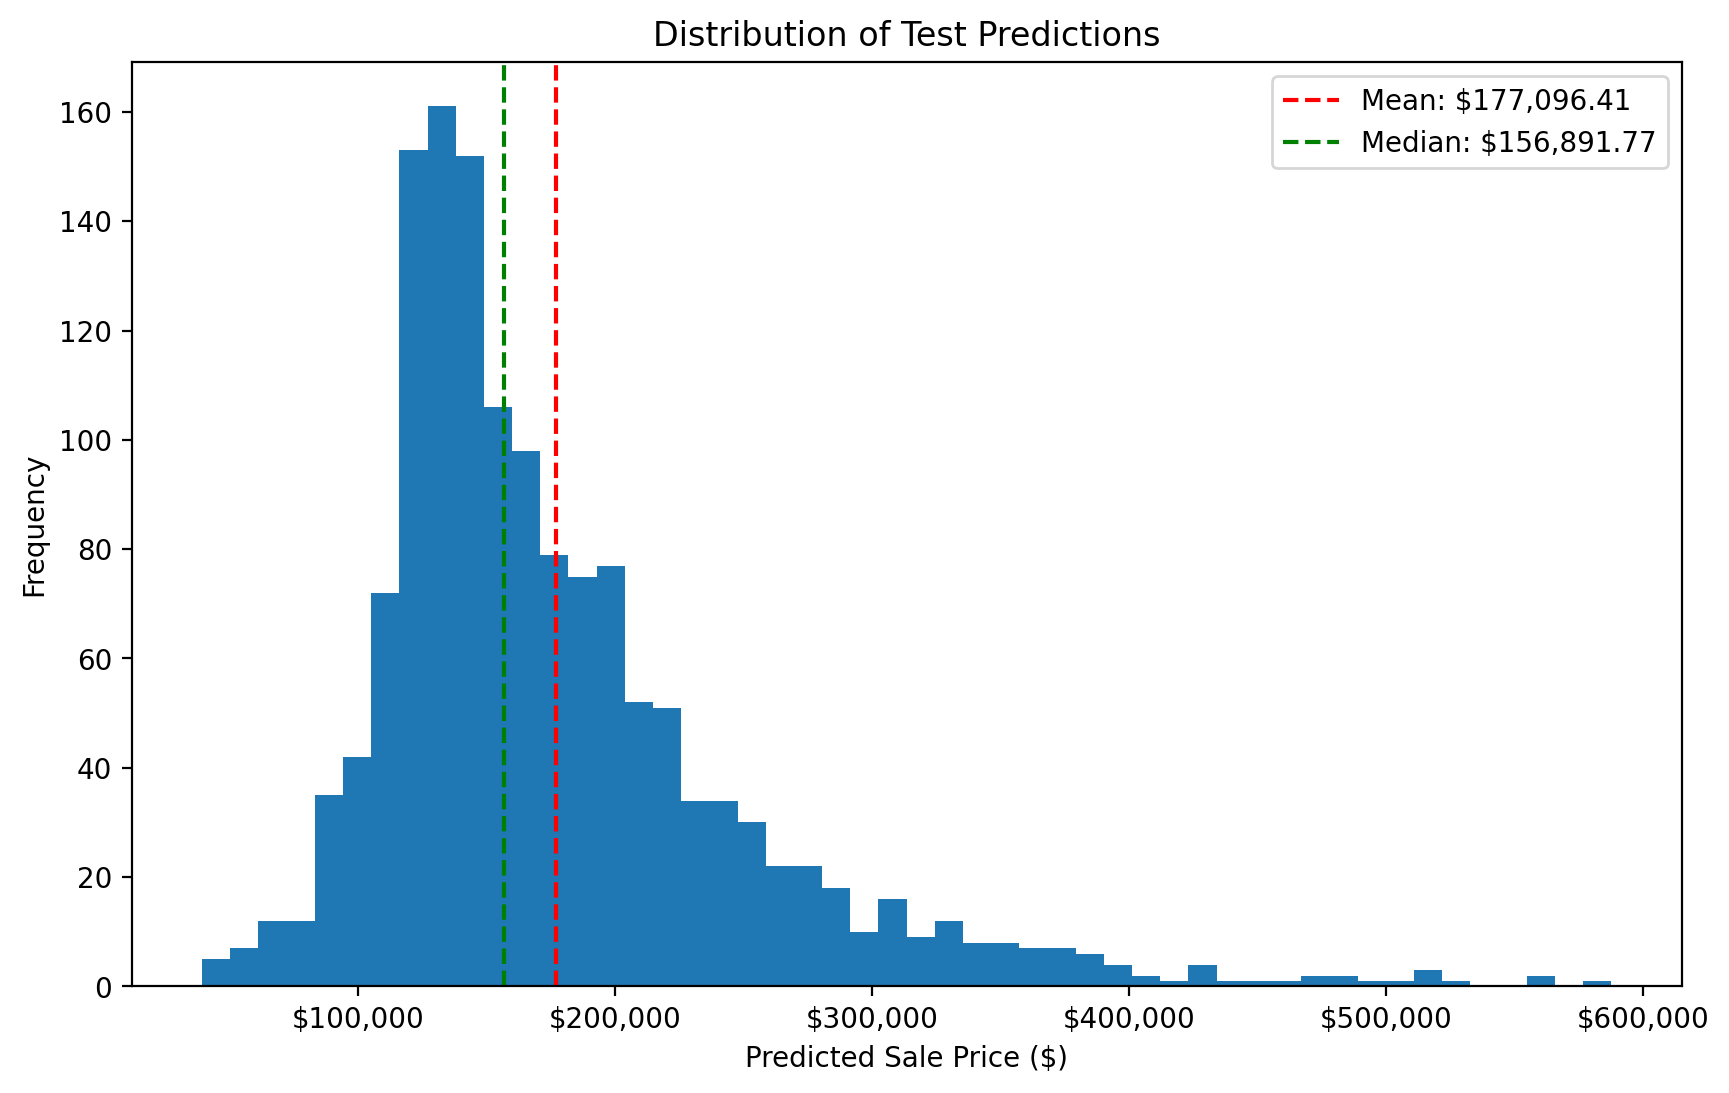


Prediction Summary:
Count: 1459
Mean: $177,096.41
Median: $156,891.77
Min: $39,336.93
Max: $587,675.89


In [ ]:
#PREDICT ON TEST SET
test_X_important = apply_feature_selection(test_df, X_train_sel.columns.tolist())

# apply same scaling and imputation
test_X_scaled = scaler_sel.transform(test_X_important)
test_X_imputed = imputer_sel.transform(test_X_scaled)

# create polynomial features
test_X_poly = poly.transform(test_X_imputed)

# make predictions in log scale
test_predictions_log = lasso_poly.predict(test_X_poly)

# Transform predictions back to original scale
test_predictions_original = np.expm1(test_predictions_log)

# create submission file (using original scale)
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_predictions_original
})
submission.to_csv('lasso_poly_submission.csv', index=False)
print(f"Predictions saved to 'lasso_poly_submission.csv'")

# plot distribution of predictions (original scale)
plt.figure(figsize=(10, 6), dpi=200)
plt.hist(submission['SalePrice'], bins=50)
plt.axvline(x=submission['SalePrice'].mean(), color='r', linestyle='--', 
            label=f'Mean: ${submission["SalePrice"].mean():,.2f}')
plt.axvline(x=submission['SalePrice'].median(), color='g', linestyle='--', 
            label=f'Median: ${submission["SalePrice"].median():,.2f}')
plt.title('Distribution of Test Predictions')
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Frequency')
plt.legend()

# Format x-axis with dollar amounts
from matplotlib.ticker import FuncFormatter
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.show()

# prediction stats (original scale)
print("\nPrediction Summary:")
print(f"Count: {len(submission)}")
print(f"Mean: ${submission['SalePrice'].mean():,.2f}")
print(f"Median: ${submission['SalePrice'].median():,.2f}")
print(f"Min: ${submission['SalePrice'].min():,.2f}")
print(f"Max: ${submission['SalePrice'].max():,.2f}")

### Gradient boosting

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best GB parameters: {'learning_rate': 0.03, 'max_depth': 3, 'max_features': 0.9, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 500, 'subsample': 0.5}
Gradient Boosting with selected features:
Training RMSE: $11,997.05
Validation RMSE: $27,308.23


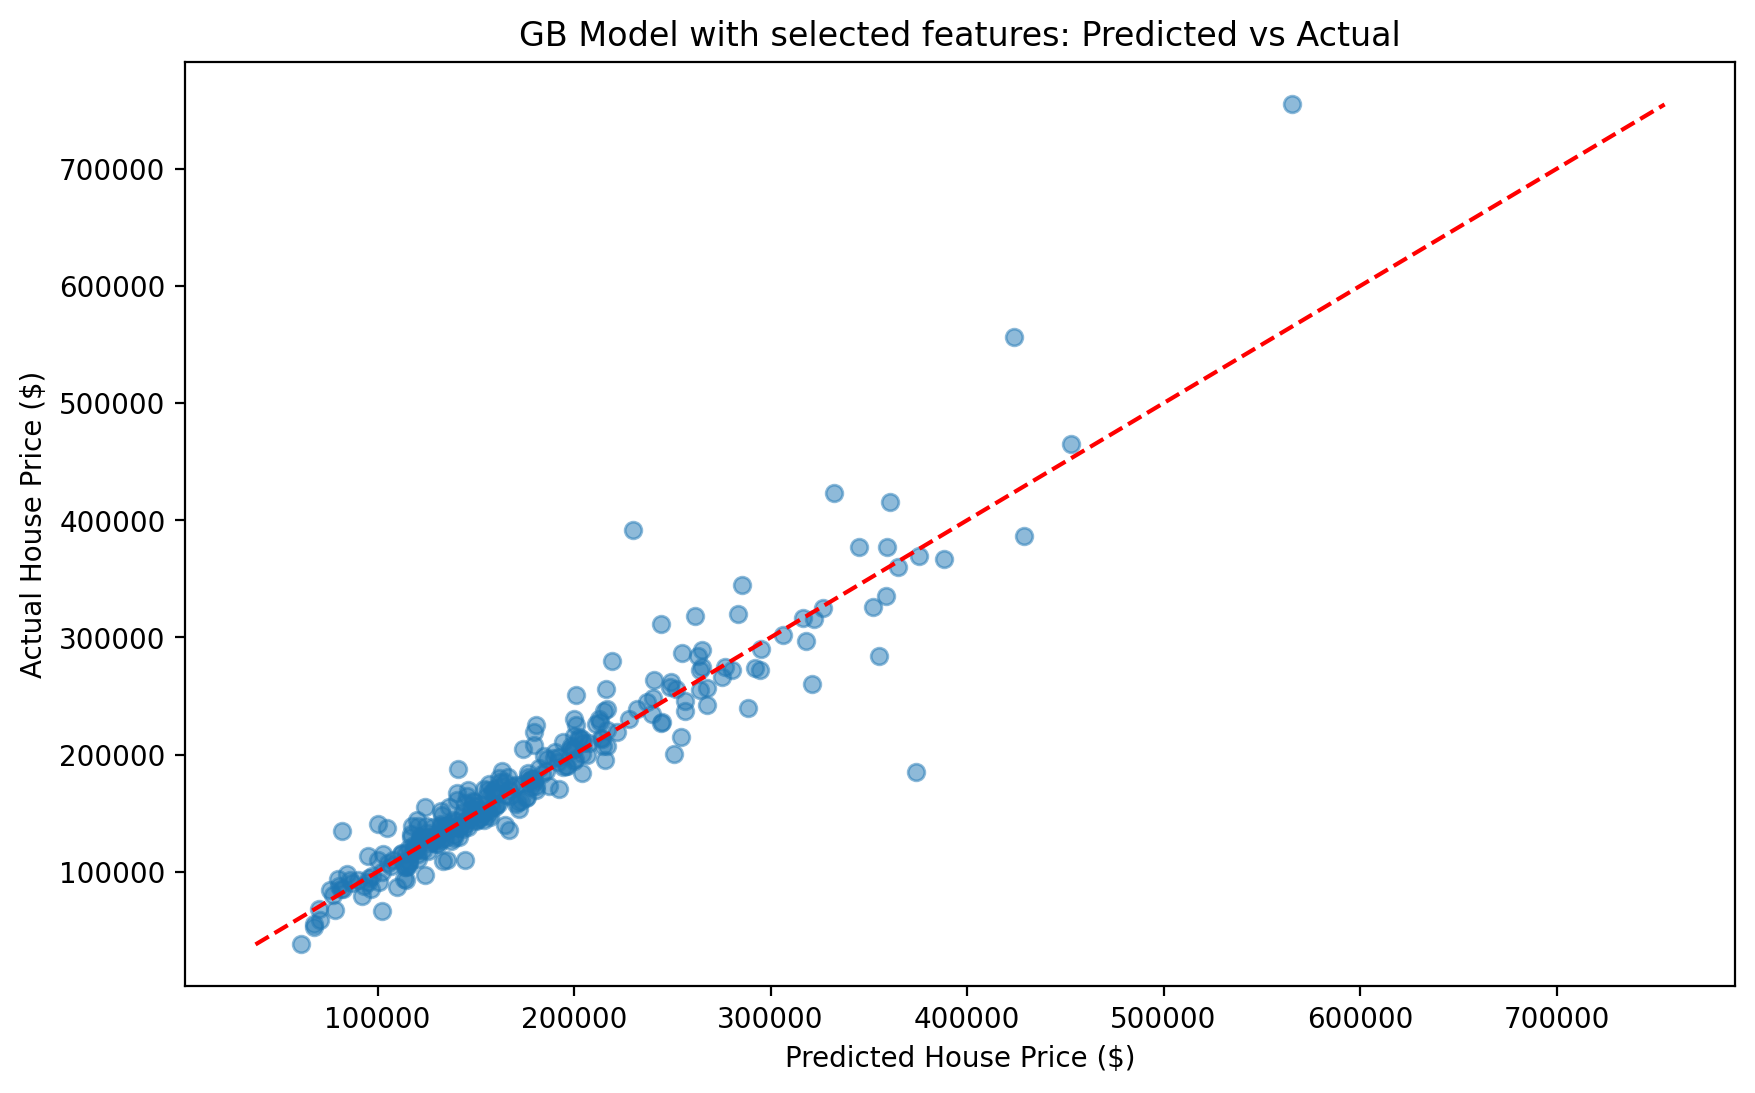

In [ ]:
# GRADIENT BOOSTING USING GB-SELECTED FEATURES
X_train_gb_sel, X_val_gb_sel, y_train_gb_sel, y_val_gb_sel = train_test_split(
    X_important_gb, y, test_size=0.2, random_state=21
)

# save original values 
y_val_original_gb = y_val_gb_sel.copy()
y_train_original_gb = y_train_gb_sel.copy()

# also log transform
y_train_log_gb = np.log1p(y_train_gb_sel)
y_val_log_gb = np.log1p(y_val_gb_sel)

# add scaler
scaler_gb = StandardScaler()
X_train_gb_scaled = scaler_gb.fit_transform(X_train_gb_sel)
X_val_gb_scaled = scaler_gb.transform(X_val_gb_sel)

imputer_gb = SimpleImputer(strategy="median")
X_train_gb_imputed = imputer_gb.fit_transform(X_train_gb_scaled)
X_val_gb_imputed = imputer_gb.transform(X_val_gb_scaled)

# these numbers has been refined
gb_param_grid = {
    'n_estimators': [400, 500],
    'learning_rate': [0.02, 0.03],
    'max_depth': [2, 3],
    'subsample': [0.5, 0.6],
    'max_features': [0.8, 0.9],
    'min_samples_leaf': [3, 4],  
    'min_samples_split': [5, 10]  
}

gb_param_grid = { # to run quicker 
    'n_estimators': [500],
    'learning_rate': [0.03],
    'max_depth': [3],
    'subsample': [0.5],
    'max_features': [ 0.9],
    'min_samples_leaf': [3], 
    'min_samples_split': [5]  
}


gb_cv = GridSearchCV(
    GradientBoostingRegressor(random_state=21), 
    gb_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1  
)

gb_cv.fit(X_train_gb_imputed, y_train_log_gb)

best_params = gb_cv.best_params_
print(f"Best GB parameters: {best_params}")

# train final model with best parameters
gb_model = GradientBoostingRegressor(**best_params, random_state=21)
gb_model.fit(X_train_gb_imputed, y_train_log_gb)

# predict 
gb_pred_train_log = gb_model.predict(X_train_gb_imputed)
gb_pred_val_log = gb_model.predict(X_val_gb_imputed)

# convert to original scale
gb_pred_train_original = np.expm1(gb_pred_train_log)
gb_pred_val_original = np.expm1(gb_pred_val_log)

# rmse
train_rmse = np.sqrt(mse(y_train_original_gb, gb_pred_train_original))
val_rmse = np.sqrt(mse(y_val_original_gb, gb_pred_val_original))

print(f"Gradient Boosting with selected features:")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Validation RMSE: ${val_rmse:,.2f}")

# plot
plt.figure(figsize=(10, 6), dpi=200)
plt.scatter(gb_pred_val_original, y_val_original_gb, alpha=0.5)
plt.plot([y_val_original_gb.min(), y_val_original_gb.max()], 
         [y_val_original_gb.min(), y_val_original_gb.max()], 'r--')
plt.xlabel('Predicted House Price ($)')
plt.ylabel('Actual House Price ($)')
plt.title('GB Model with selected features: Predicted vs Actual')
plt.show()

Predictions saved to 'gradient_boosting_submission.csv'

Prediction Summary:
Count: 1459
Mean: $177,204.30
Median: $156,492.25
Min: $40,567.98
Max: $562,652.77


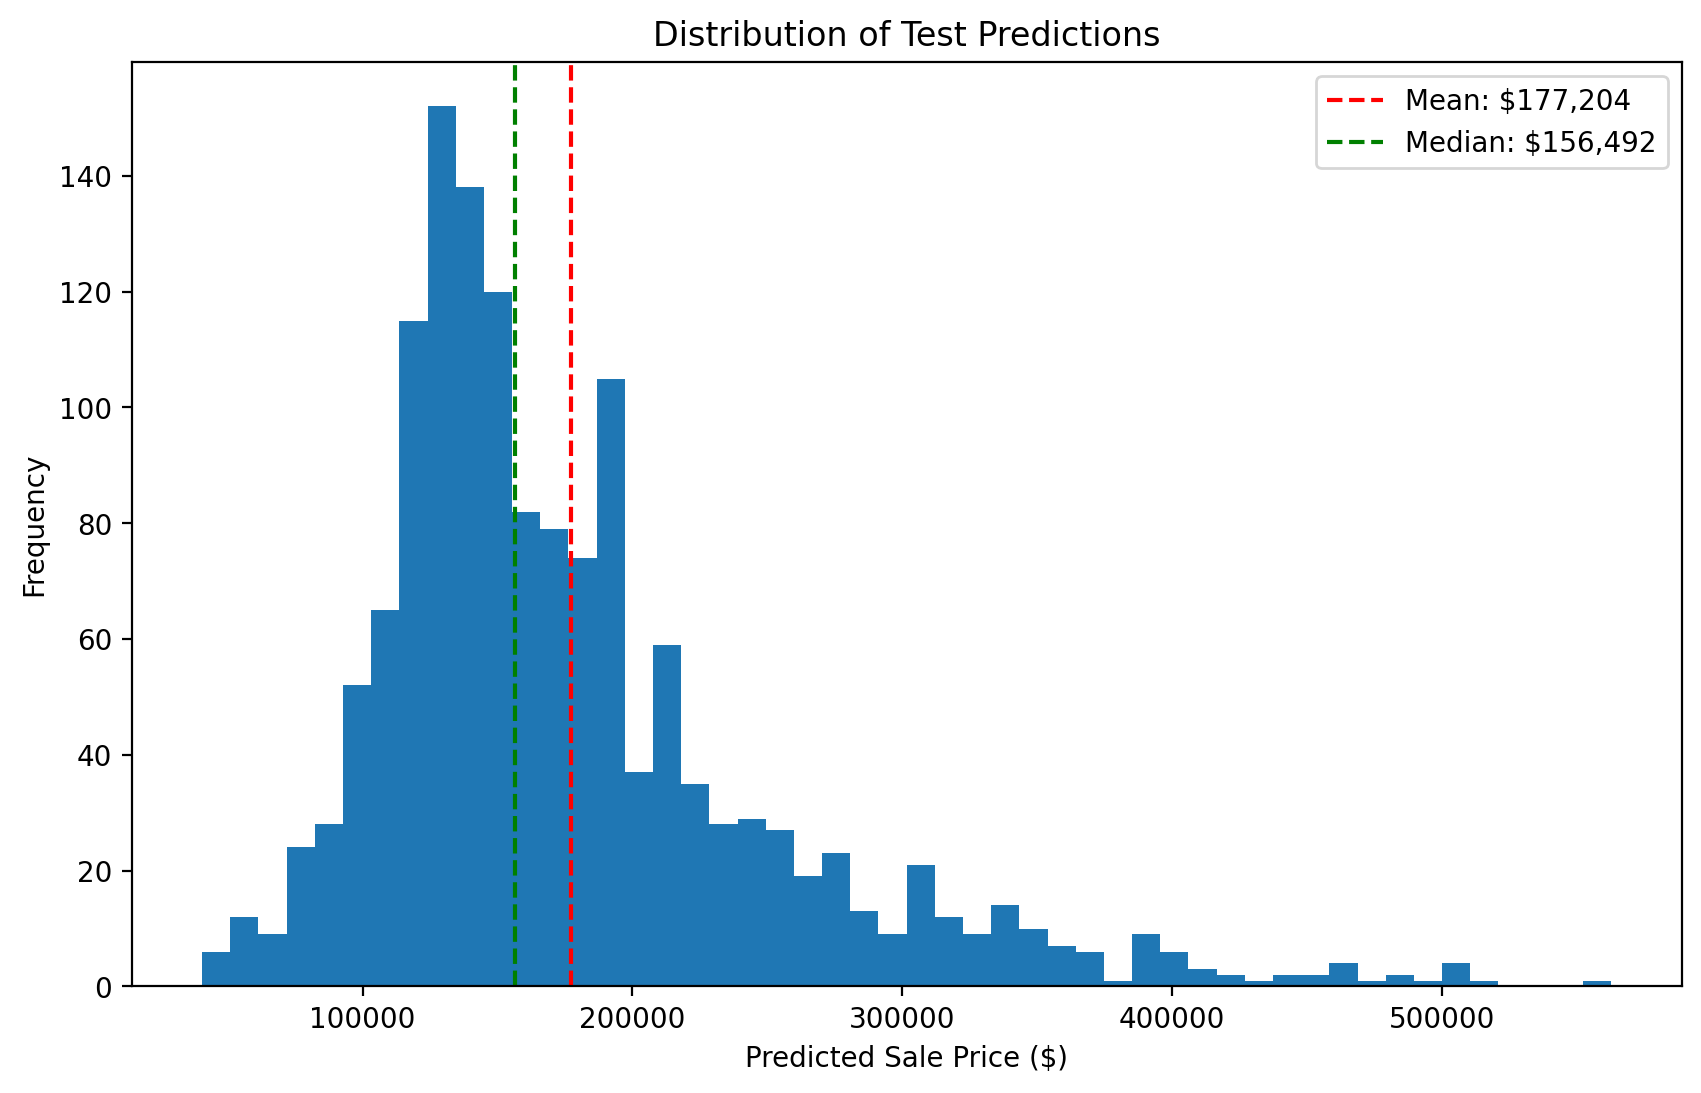

In [ ]:
# APPLY MODEL TO TEST DATA AND CREATE SUBMISSION FILE
test_X_important = apply_feature_selection(test_df, important_feature_names_gb)

# same preprocessing 
test_X_scaled = scaler_gb.transform(test_X_important)
test_X_imputed = imputer_gb.transform(test_X_scaled)

# predict
test_predictions_log = gb_model.predict(test_X_imputed)

# transform back to original scale
test_predictions_original = np.expm1(test_predictions_log)

# create file with ids stored from the beginning 
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': test_predictions_original
})

# save
submission_file = 'gradient_boosting_submission.csv'
submission.to_csv(submission_file, index=False)
print(f"Predictions saved to '{submission_file}'")

# stats
print("\nPrediction Summary:")
print(f"Count: {len(submission)}")
print(f"Mean: ${submission['SalePrice'].mean():,.2f}")
print(f"Median: ${submission['SalePrice'].median():,.2f}")
print(f"Min: ${submission['SalePrice'].min():,.2f}")
print(f"Max: ${submission['SalePrice'].max():,.2f}")

# plot
plt.figure(figsize=(10, 6), dpi=200)
plt.hist(submission['SalePrice'], bins=50)
plt.axvline(x=submission['SalePrice'].mean(), color='r', linestyle='--', 
            label=f'Mean: ${submission["SalePrice"].mean():,.0f}')
plt.axvline(x=submission['SalePrice'].median(), color='g', linestyle='--', 
            label=f'Median: ${submission["SalePrice"].median():,.0f}')
plt.title('Distribution of Test Predictions')
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()